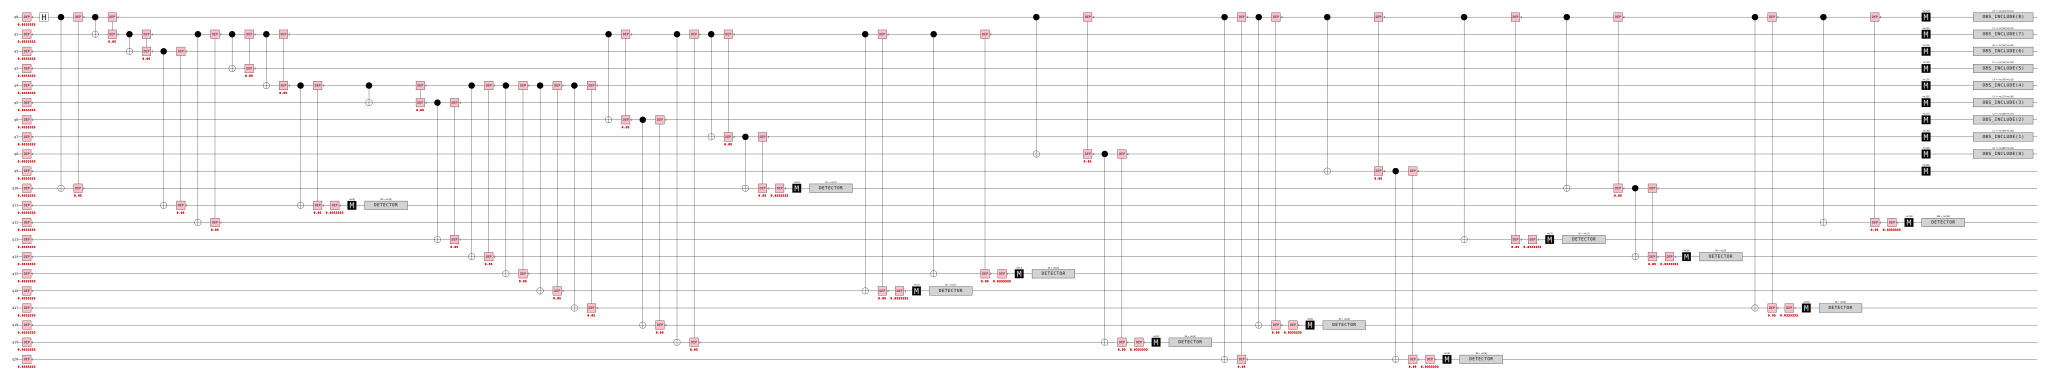

In [27]:
from spidercat.simulate import add_measurements
from spidercat.circuit_extraction import make_stim_circ_noisy

import stim

n = 10
p = 0.05
with open(f"../spidercat/circuits/cat_state_tinf_n{n}_p1.stim", "r") as f:
    circ = stim.Circuit(f.read())

noisy_circ = make_stim_circ_noisy(circ, p_2=p, p_init=2 / 3 * p, p_meas=2 / 3 * p, p_mem=0)
add_measurements(noisy_circ, n, "spider-cat")
for i in range(n - 1):
    noisy_circ.append("OBSERVABLE_INCLUDE", [stim.target_rec(-1 - i), stim.target_rec(-2 - i)],i)

noisy_circ.diagram('timeline-svg')

In [46]:
import tesseract_decoder
import tesseract_decoder.tesseract as tesseract
import numpy as np
import time


# Helper functions for benchmarking

def print_results(results):
    print("Tesseract Decoder Stats:")
    print(f"   Number of Errors / num_shots: {results['num_errors']} / {results['num_shots']}")
    print(f"   Time: {results['time_seconds']:.4f} s")
    print()

def get_num_errors(observables):
    num_shots = observables.shape[0]
    n = observables.shape[1] + 1
    relative_errors = np.cumsum(observables, axis=1) % 2
    zeros_column = np.zeros((num_shots, 1), dtype=int)
    full_error_strings = np.hstack((zeros_column, relative_errors))
    weight_ones = np.sum(full_error_strings, axis=1)
    return np.minimum(weight_ones, n - weight_ones)


def run_tesseract_decoder(decoder, dets, obs):
    # Run and time the Tesseract decoder
    num_errors = 0
    start_time = time.time()
    obs_predicted = decoder.decode_batch(dets)
    print()
    print("Original samples:", get_num_errors(obs))
    print("Decoded samples: ", get_num_errors(obs_predicted != obs))

    num_errors = np.sum(np.any(obs_predicted != obs, axis=1))
    end_time = time.time()

    return {
        'num_errors': num_errors,
        'num_shots': len(dets),
        'time_seconds': end_time - start_time,
    }


num_shots = 30
sampler = noisy_circ.compile_detector_sampler()
detector_outcomes, actual_observables = sampler.sample(shots=num_shots, separate_observables=True)
dem = noisy_circ.detector_error_model(decompose_errors=False)


# setup the tesseract decoder configuration
tesseract_config = tesseract.TesseractConfig(
    dem=dem,
    pqlimit=100000,
    no_revisit_dets=True,
    # verbose=True,
    det_orders=tesseract_decoder.utils.build_det_orders(
        dem, num_det_orders=1,
        method=tesseract_decoder.utils.DetOrder.DetIndex,
        seed=2384753),
)
tesseract_dec = tesseract_config.compile_decoder()

results = run_tesseract_decoder(tesseract_dec, detector_outcomes, actual_observables)
print_results(results)


Original samples: [0 1 4 2 1 1 3 2 1 2 3 2 0 0 0 2 0 0 4 0 0 3 2 4 1 1 2 1 2 0]
Decoded samples:  [0 0 3 0 1 0 0 1 0 0 3 1 0 0 0 2 0 0 1 0 0 1 1 3 1 1 2 0 2 0]
Tesseract Decoder Stats:
   Number of Errors / num_shots: 14 / 30
   Time: 0.0014 s

